In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta import TVqRegularized
from bimpcc.models.tvq_denoising import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 15

In [5]:
dataset = get_dataset("guacamayo",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(14.5), np.float64(14.5), np.float64(-0.5))

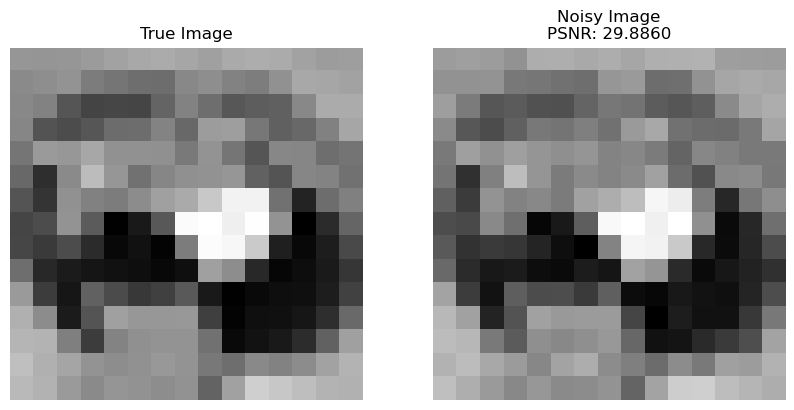

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [19]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.65)

In [20]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

alpha= [100.]
alpha= [100.]
alpha= [100.]
alpha= [99.99758515]
alpha= [99.68696314]
alpha= [99.68785833]
alpha= [99.74528418]
alpha= [99.8409893]
alpha= [99.85007859]
alpha= [99.85910732]
alpha= [99.85544008]
alpha= [99.85928121]
alpha= [99.86114893]
alpha= [99.86151134]
alpha= [99.86073253]
alpha= [99.89014165]
alpha= [99.9437689]
alpha= [100.07520935]
alpha= [100.40317859]
alpha= [101.34396846]
alpha= [108.49919937]
alpha= [127.02547054]
alpha= [125.0605453]
alpha= [230.19811808]
alpha= [230.25633515]
alpha= [237.32392824]
alpha= [275.27012939]
alpha= [274.04417174]
alpha= [274.03688144]
alpha= [273.97487232]
alpha= [274.00050233]
alpha= [274.02231686]
alpha= [274.01793803]
alpha= [274.01855896]
alpha= [274.01859295]
alpha= [274.01911538]
alpha= [274.02531763]


In [21]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

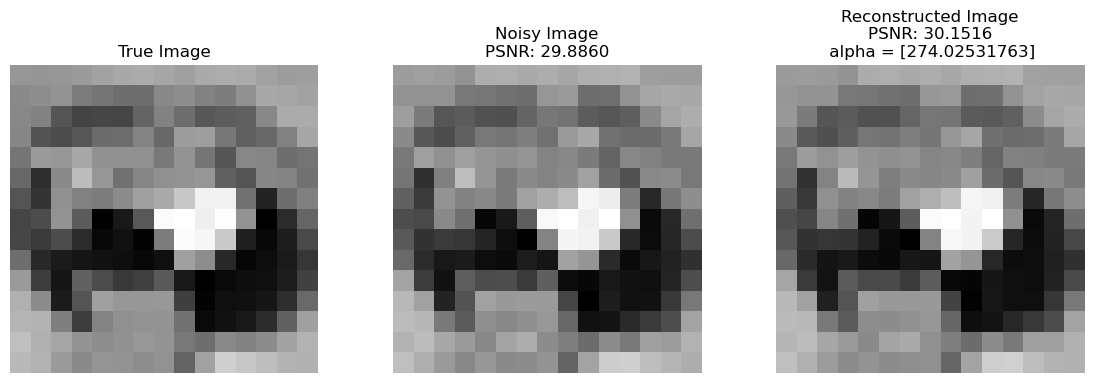

In [22]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)